# 1. Define Problem Statement and Perform Exploratory Data Analysis 

## 1.1 Definition of Problem

Delhivery, India's largest logistics company, wants to leverage data from its logistics operations to improve efficiency, optimize deliveries, and enhance forecasting models. The goal is to:

-    Clean and preprocess the data to create meaningful features.
-    Explore the relationships between various logistics metrics (e.g., actual vs. predicted delivery times).
-    Identify inefficiencies, bottlenecks, and potential areas of improvement in delivery performance.
-    Support the data science team in building forecasting models.

Key Questions to Address:

-    How well does the actual delivery time align with OSRM (predicted) delivery time?
-    Are there patterns in delivery delays across different routes, transportation types, or regions?
-    What factors influence delivery times and deviations from the expected schedule?

In [1]:
# Reload the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
pd.set_option("display.max_columns", 50)

file_path = r"data\raw\data.csv"
df = pd.read_csv(file_path)
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


## 1.2 Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary.

In [2]:
# 1. Checking the shape of the dataset (number of rows and columns)
shape_info = df.shape

# 2. Checking data types of all attributes
data_types = df.dtypes

# 3. Converting categorical attributes to 'category' type if required
categorical_cols = ["route_type", "source_name", "destination_name"]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# 4. Checking for missing values
missing_values = df.isnull().sum()

# 5. Getting statistical summary of numerical attributes
stat_summary = df.describe()

# Display results
shape_info, data_types, missing_values, stat_summary

((144867, 24),
 data                               object
 trip_creation_time                 object
 route_schedule_uuid                object
 route_type                         object
 trip_uuid                          object
 source_center                      object
 source_name                        object
 destination_center                 object
 destination_name                   object
 od_start_time                      object
 od_end_time                        object
 start_scan_to_end_scan            float64
 is_cutoff                            bool
 cutoff_factor                       int64
 cutoff_timestamp                   object
 actual_distance_to_destination    float64
 actual_time                       float64
 osrm_time                         float64
 osrm_distance                     float64
 factor                            float64
 segment_actual_time               float64
 segment_osrm_time                 float64
 segment_osrm_distance             floa

## 1.3 Visual Analysis (Distribution Plots of all the Continuous Variable(s), Box Plots of all the Categorical Variables)

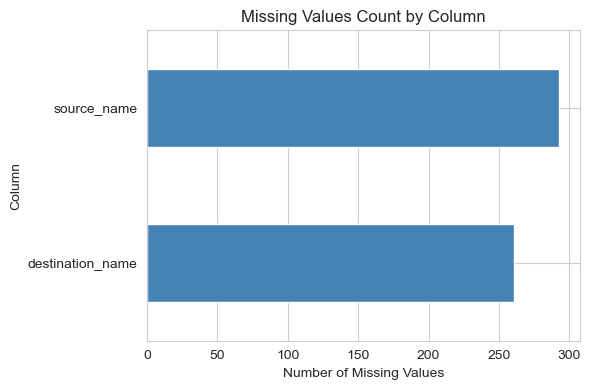

In [13]:
missing = df.isna().sum()
missing = missing[missing > 0]

plt.figure(figsize=(6, 4))
missing.sort_values().plot(kind="barh", color="steelblue")

plt.title("Missing Values Count by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig("figures\Missing_Values_Count_by_Column.png")
plt.show()

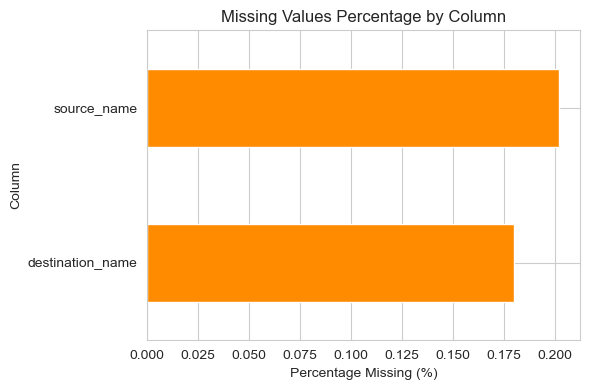

In [14]:
missing_pct = (df.isna().mean() * 100)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(6, 4))
missing_pct.sort_values().plot(kind="barh", color="darkorange")

plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage Missing (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig("figures\Missing_Values_Percentage_by_Column.png")
plt.show()

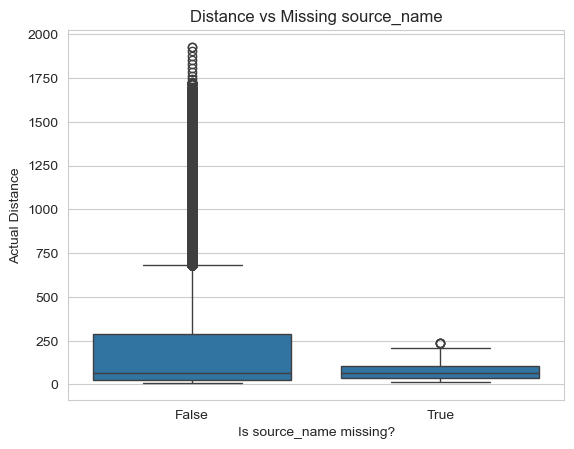

In [15]:
sns.boxplot(
    x=df["source_name"].isna(),
    y=df["actual_distance_to_destination"]
)

plt.xlabel("Is source_name missing?")
plt.ylabel("Actual Distance")
plt.title("Distance vs Missing source_name")
plt.savefig("figures\Distance_vs_Missing_source_name.png")
plt.show()

In [18]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": df.isna().mean() * 100
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]
missing_summary

,Missing Count,Missing %
source_name,293,0.202254
destination_name,261,0.180165


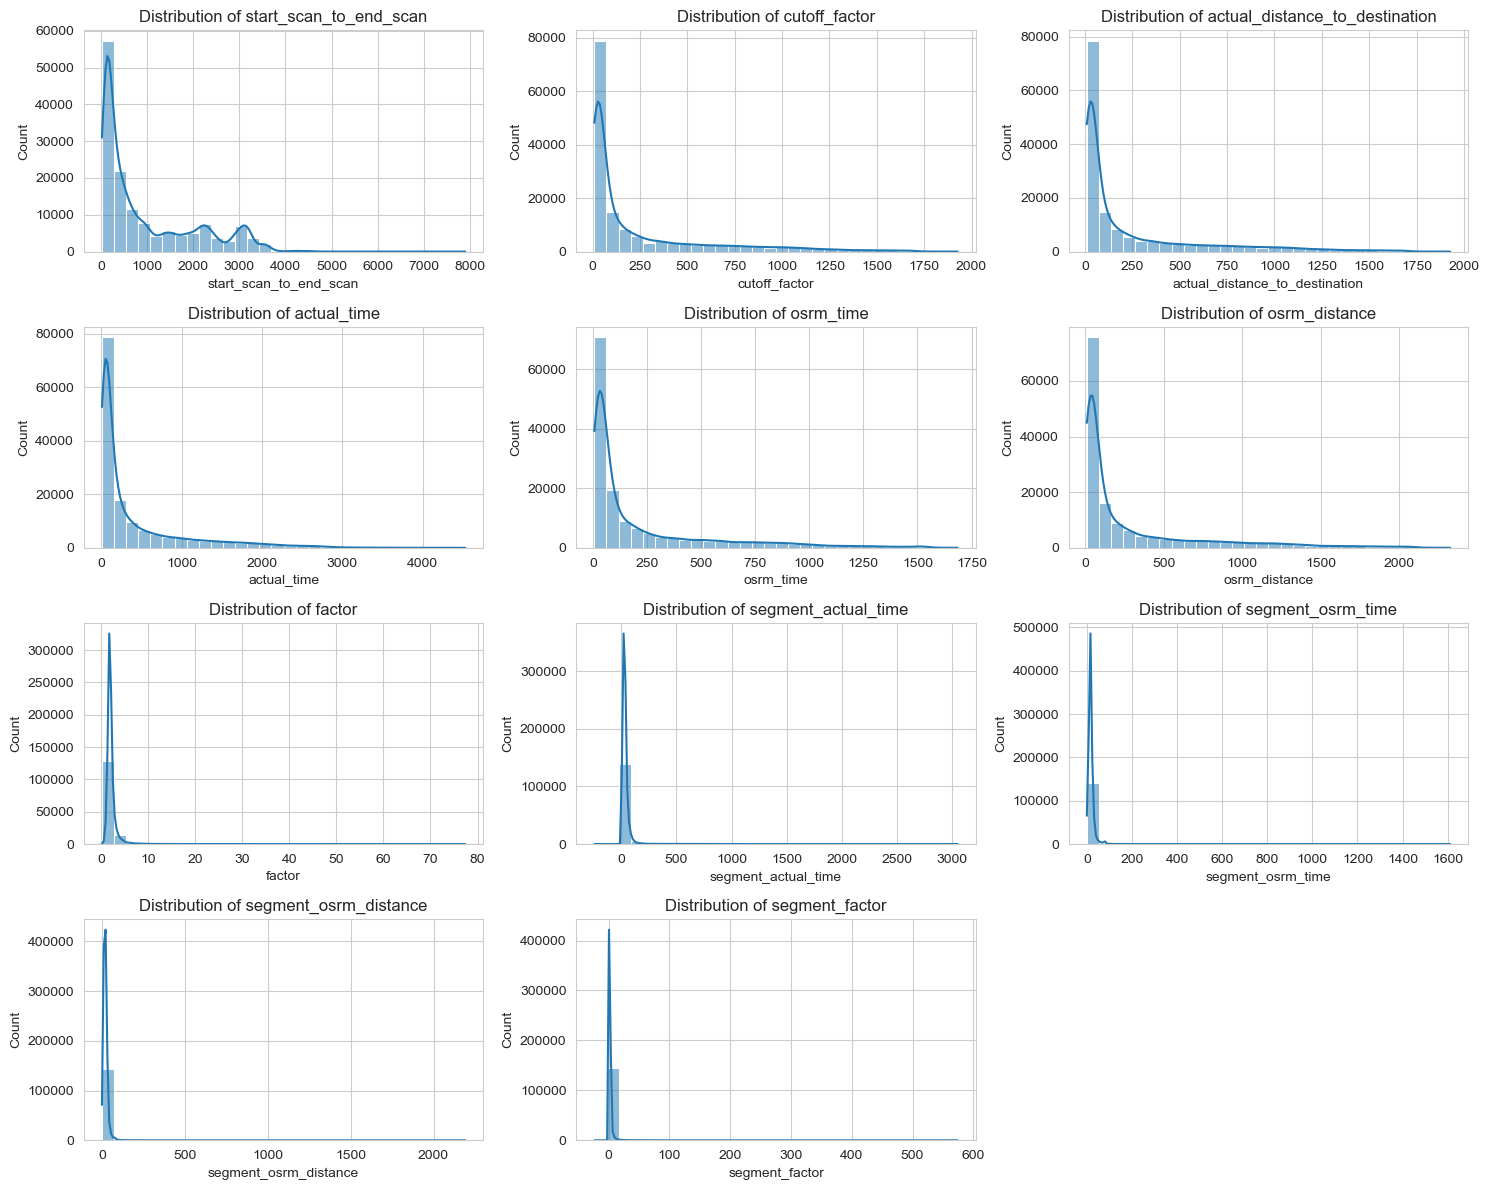

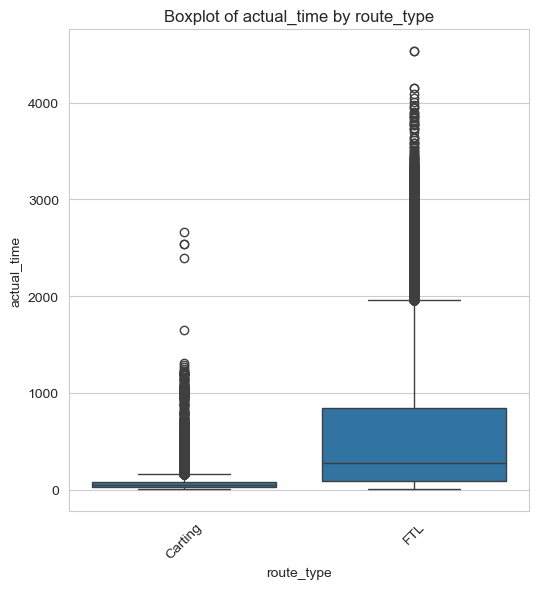

In [3]:
# Setting the style for the plots
sns.set_style("whitegrid")

# Identifying continuous variables (numerical)
continuous_vars = df.select_dtypes(include=['float64', 'int64']).columns

# Plotting distribution plots for continuous variables
plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.savefig(f"figures\Distribution_of_{col}.png")
plt.tight_layout()
plt.show()

# Identifying categorical variables (excluding high-cardinality ones)
categorical_vars = ["route_type", "source_name", "destination_name"]

# Plotting boxplots for categorical variables against actual delivery time
plt.figure(figsize=(15, 6))
for i, col in enumerate(categorical_vars, 1):
    if df[col].nunique() < 15:  # Limiting to categories with fewer unique values for readability
        plt.subplot(1, 3, i)
        sns.boxplot(x=df[col], y=df["actual_time"])
        plt.xticks(rotation=45)
        plt.title(f"Boxplot of actual_time by {col}")
        plt.savefig(f"figures\Boxplot_of_actual_time_by_{col}.png")
plt.tight_layout()
plt.show()

## 1.4 Insights based on EDA

### 1.4.1 Comments on range of attributes, outliers of various attributes.

**Actual Delivery Time (*actual_time*):**

-    Ranges from 9 minutes to 4,532 minutes.
-    Presence of extreme values suggests potential outliers.
-    Some deliveries take significantly longer than expected.

**OSRM-Predicted Delivery Time (*osrm_time*):**

-    Ranges from 6 minutes to 1,686 minutes.
-    The difference between *actual_time* and *osrm_time* indicates possible inefficiencies in routing or external factors affecting delivery.

**Distance (*osrm_distance* and *actual_distance_to_destination*):**

-    The maximum distance covered is over 2,300 km, suggesting long-haul shipments.
-    Outliers in distance might indicate incorrect data entries or rare cases of extreme distances.

**Segment Time and Factors (*segment_actual_time*, *segment_osrm_time*, *segment_factor*):**

-    Some segment times have negative values, which need further investigation.
-    *segment_factor* has extreme variations, with a max value of 574.25 and a min value of -23.44, possibly indicating data recording errors or unpredictable delivery conditions.

### 1.4.2 Comments on the distribution of the variables and relationship between them

**Distribution Observations:**

-    Most numerical attributes show right-skewed distributions, meaning a majority of deliveries are completed quickly, but a few take significantly longer.
-    *actual_time* has a long tail, indicating that some deliveries face extreme delays.
Relationships Between Key Variables:

***actual_time* vs. *osrm_time*:**

-    Positive correlation observed (higher *osrm_time* generally corresponds to higher *actual_time*).
-    However, actual time often exceeds OSRM-predicted time, hinting at delays due to real-world challenges (traffic, weather, warehouse issues).

***actual_time* vs. *route_type*:**

-    Full Truck Load (FTL) shipments tend to have more predictable and shorter delivery times.
-    Carting shipments show more variability and potential delays, likely due to multiple stops.

***actual_time* vs. *destination_city/source_city*:**

-    Certain cities have consistently longer delivery times, possibly due to traffic congestion or warehouse processing delays.

### 1.4.3 Comments for each Univariate and Bivariate Plot

**Distribution Plots:**

-    Most continuous variables have right-skewed distributions.
-    *actual_time* and *segment_actual_time* have long tails, meaning a few deliveries take unusually long.
-    *osrm_distance* and *actual_distance_to_destination* are positively skewed, indicating that most deliveries are relatively short, with a few exceptionally long ones.

**Boxplots for Categorical Variables:**

-    Route Type (*route_type*):
    -    FTL shipments have lower variability in delivery time.
    -     Carting shipments exhibit greater variance and higher median delivery times.

**Source and Destination Cities:**

-    Some cities have consistently longer actual times, possibly due to operational inefficiencies.
-    Outliers in boxplots suggest certain locations experience extreme delivery delays.

# 2. Feature Creation

In [4]:
# Convert datetime columns to proper datetime format
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["od_start_time"] = pd.to_datetime(df["od_start_time"])
df["od_end_time"] = pd.to_datetime(df["od_end_time"])

# Feature 1: Extract Year, Month, Day, Hour, Weekday from trip_creation_time
df["trip_year"] = df["trip_creation_time"].dt.year
df["trip_month"] = df["trip_creation_time"].dt.month
df["trip_day"] = df["trip_creation_time"].dt.day
df["trip_hour"] = df["trip_creation_time"].dt.hour
df["trip_weekday"] = df["trip_creation_time"].dt.weekday  # Monday=0, Sunday=6

# Feature 2: Compute total time taken between od_start_time and od_end_time
df["trip_duration"] = (df["od_end_time"] - df["od_start_time"]).dt.total_seconds() / 60  # Convert to minutes

# Feature 3: Extract city and state from source_name and destination_name
df[["source_city", "source_state"]] = df["source_name"].str.rsplit("-", n=1, expand=True)[0].str.split("(", expand=True)
df["source_state"] = df["source_state"].str.split(")", expand=True)[0]
df[["destination_city", "destination_state"]] = df["destination_name"].str.rsplit("-", n=1, expand=True)[0].str.split("(",expand=True)
df["destination_state"] = df["destination_state"].str.split(")", expand=True)[0]

# Feature 4: One-hot encoding for route_type
df = pd.get_dummies(df, columns=["route_type"], drop_first=True)
df

,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,trip_year,trip_month,trip_day,trip_hour,trip_weekday,trip_duration,source_city,source_state,destination_city,destination_state,route_type_FTL
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727,2018,9,20,2,3,86.213637,Anand_VUNagar_DC,Gujarat,Khambhat_MotvdDPP_D,Gujarat,False
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111,2018,9,20,2,3,86.213637,Anand_VUNagar_DC,Gujarat,Khambhat_MotvdDPP_D,Gujarat,False
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714,2018,9,20,2,3,86.213637,Anand_VUNagar_DC,Gujarat,Khambhat_MotvdDPP_D,Gujarat,False
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000,2018,9,20,2,3,86.213637,Anand_VUNagar_DC,Gujarat,Khambhat_MotvdDPP_D,Gujarat,False
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000,2018,9,20,2,3,86.213637,Anand_VUNagar_DC,Gujarat,Khambhat_MotvdDPP_D,Gujarat,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,45,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000,2018,9,20,16,3,427.686364,Sonipat_Kundli_H,Haryana,Gurgaon_Bilaspur_HB,Haryana,False
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,54,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095,2018,9,20,16,3,427.686364,Sonipat_Kundli_H,Haryana,Gurgaon_Bilaspur_HB,Haryana,False
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,63,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.705

# 3. Merging of rows and aggregation of fields 

In [5]:
# Convert timestamp columns to datetime
datetime_cols = ["trip_creation_time", "od_start_time", "od_end_time"]
df[datetime_cols] = df[datetime_cols].apply(pd.to_datetime)

# Define aggregation rules for merging rows based on 'trip_uuid'
agg_rules = {
    "trip_creation_time": "first",  # Keep the first trip creation time
    "route_schedule_uuid": "first",
    "route_type": "first",
    "source_center": "first",
    "source_name": "first",
    "destination_center": "first",
    "destination_name": "first",
    "od_start_time": "first",  # First recorded start time
    "od_end_time": "last",  # Last recorded end time
    "start_scan_to_end_scan": "sum",
    "actual_distance_to_destination": "sum",
    "actual_time": "sum",
    "osrm_time": "sum",
    "osrm_distance": "sum",
    "factor": "mean",
    "segment_actual_time": "sum",
    "segment_osrm_time": "sum",
    "segment_osrm_distance": "sum",
    "segment_factor": "mean",
}

# Perform the aggregation by trip_uuid
df_aggregated = df.groupby("trip_uuid").agg(agg_rules).reset_index()

# Compute total trip duration (from start to end)
df_aggregated["trip_duration"] = (df_aggregated["od_end_time"] - df_aggregated["od_start_time"]).dt.total_seconds() / 60
df_aggregated

,trip_uuid,trip_creation_time,route_schedule_uuid,route_type,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,trip_duration
0,trip-153671041653548748,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,43659.0,8860.812105,15682.0,7787.0,10577.7647,1.962054,1548.0,1008.0,1320.4733,2.022887,2260.109800
1,trip-153671042288605164,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,906.0,240.208306,399.0,210.0,269.4308,1.832792,141.0,65.0,84.1894,2.540564,181.611874
2,trip-153671043369099517,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,248631.0,68163.502238,112225.0,65768.0,89447.2488,1.703628,3308.0,1941.0,2545.2678,1.797082,3934.362520
3,trip-153671046011330457,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,Mumbai Hub (Maharashtra),IND401104AAA,Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,200.0,28.529648,82.0,24.0,31.6475,3.244444,59.0,16.0,19.8766,3.849206,100.494935
4,trip-153671052974046625,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,Bellary_Dc (Karnataka),IND583201AAA,Hospet (Karnataka),2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,1586.0,239.007304,556.0,207.0,266.2914,2.573923,340.0,115.0,146.7919,3.364728,718.349042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14812,trip-153861095625827784,2018-10-03 23:55:56.258533,thanos::sroute:8a120994-f577-4491-9e4b-b7e4a14...,Carting,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),IND140603AAA,Zirakpur_DC (Punjab),2018-10-03 23:55:56.258533,2018-10-04 06:41:25.409035,876.0,141.057373,186.0,148.0,162.9473,1.301065,82.0,62.0,64.8551,1.514224,405.485842
14813,trip-153861104386292051,2018-10-03 23:57:23.863155,thanos::sroute:b30e1ec3-3bfa-4bd2-a7fb-3b75769...,Carting,IND121004AAB,FBD_Balabhgarh_DPC (Haryana),IND121004AAA,Faridabad_Blbgarh_DC (Haryana),2018-10-03 23:57:23.863155,2018-10-04 00:57:59.294434,120.0,25.130640,33.0,19.0,26.5333,1.732143,21.0,11.0,16.0883,1.982143,60.590521
14814,trip-153861106442901555,2018-10-03 23:57:44.429324,thanos::sroute:5609c268-e436-4e0a-8180-3db4a74...,Carting,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND208006AAA,Kanpur_GovndNgr_DC (Uttar Pradesh),2018-10-03 23:57:44.429324,2018-10-04 06:59:51.621332,1263.0,93.743842,549.0,134.0,162.8499,3.880469,281.0,88.0,104.8866,3.727787,422.119867
14815,trip-153861115439069069,2018-10-03 23:59:14.390954,thanos::sroute:c5f2ba2c-8486-4940-8af6-d1d2a6a...,Carting,IND627005AAA,Tirunelveli_VdkkuSrt_I (Tamil Nadu),IND628801AAA,Eral_Busstand_D (Tamil Nadu),2018-10-03 23:59:14.390954,2018-10-04 05:47:45.162682,1315.0,355.281673,600.0,446.0,449.5383,1.388275,258.0,221.0,223.5324,1.234944,348.512862


# 4. Comparison & Visualization of time and distance fields

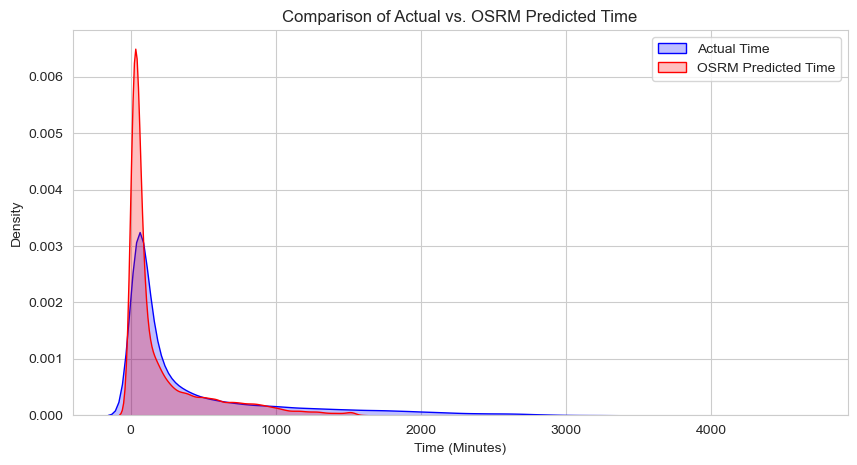

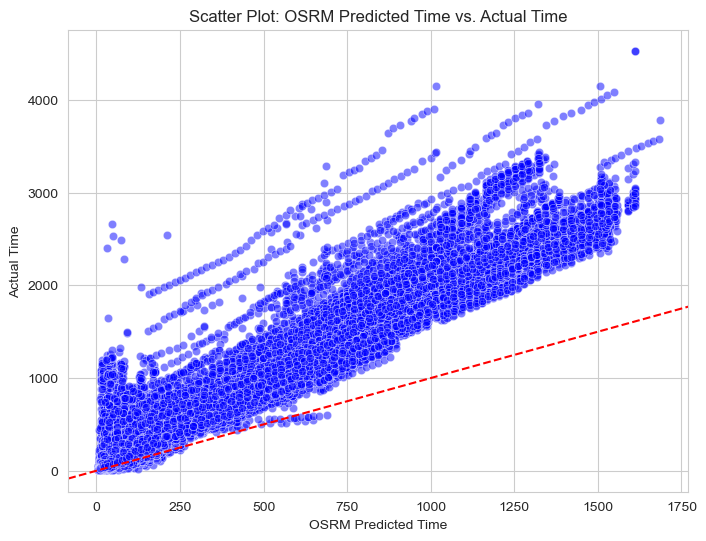

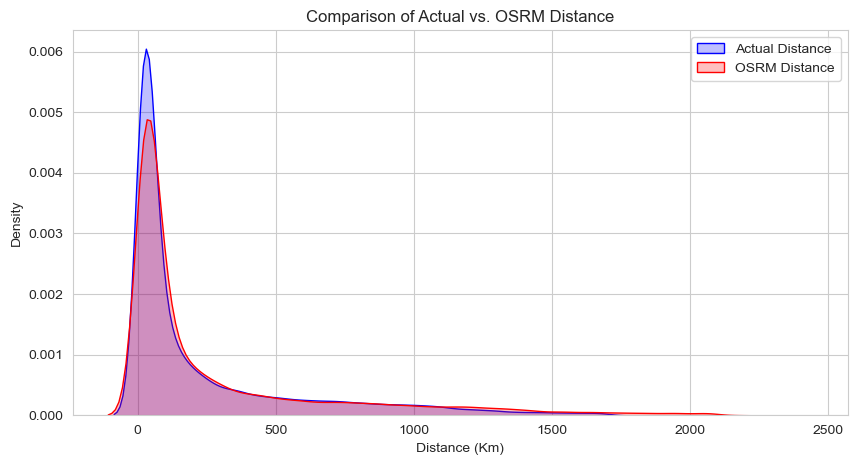

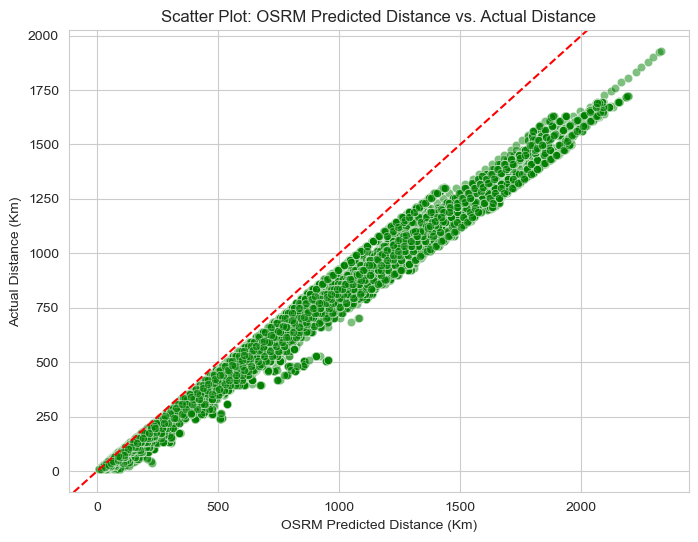

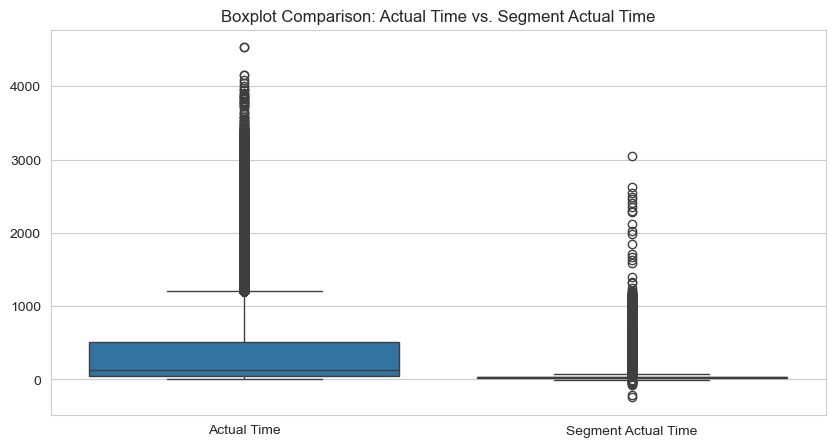

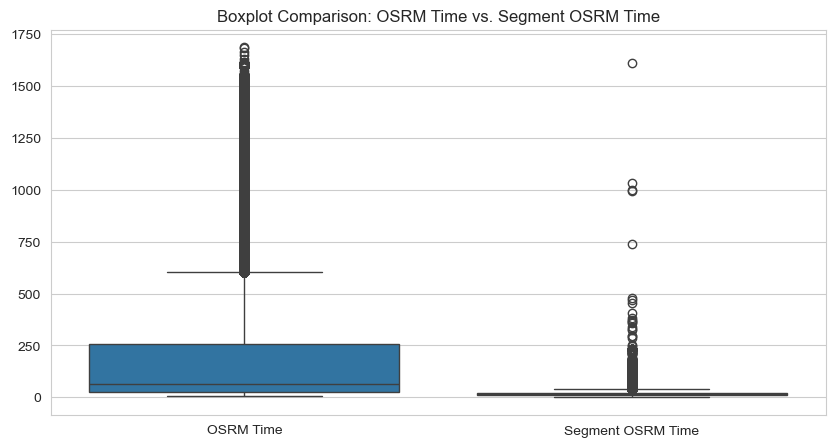

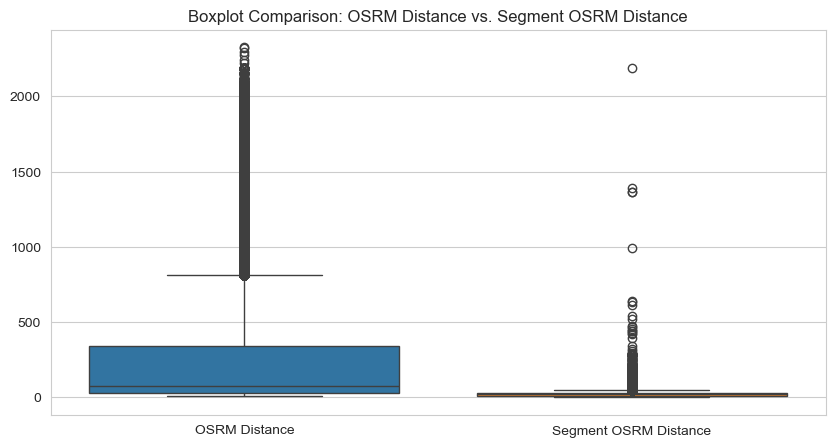

In [6]:
# Convert datetime columns to proper format
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["od_start_time"] = pd.to_datetime(df["od_start_time"])
df["od_end_time"] = pd.to_datetime(df["od_end_time"])

# Compute trip duration
df["trip_duration"] = (df["od_end_time"] - df["od_start_time"]).dt.total_seconds() / 60  # Convert to minutes

# Set seaborn style
sns.set_style("whitegrid")

# 1. Distribution of Actual Time vs. OSRM Predicted Time
plt.figure(figsize=(10, 5))
sns.kdeplot(df["actual_time"], label="Actual Time", fill=True, color="blue")
sns.kdeplot(df["osrm_time"], label="OSRM Predicted Time", fill=True, color="red")
plt.title("Comparison of Actual vs. OSRM Predicted Time")
plt.xlabel("Time (Minutes)")
plt.ylabel("Density")
plt.legend()
plt.savefig("figures\Comparison_of_Actual_vs_OSRM_Predicted_Time.png")
plt.show()

# 2. Scatter Plot: Actual Time vs. OSRM Time
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["osrm_time"], y=df["actual_time"], alpha=0.5, color="blue")
plt.axline((0, 0), slope=1, linestyle="--", color="red")  # Diagonal reference line
plt.xlabel("OSRM Predicted Time")
plt.ylabel("Actual Time")
plt.title("Scatter Plot: OSRM Predicted Time vs. Actual Time")
plt.savefig("figures\Scatter_Plot_of_Actual_vs_OSRM_Predicted_Time.png")
plt.show()

# 3. Distribution of Actual Distance vs. OSRM Distance
plt.figure(figsize=(10, 5))
sns.kdeplot(df["actual_distance_to_destination"], label="Actual Distance", fill=True, color="blue")
sns.kdeplot(df["osrm_distance"], label="OSRM Distance", fill=True, color="red")
plt.title("Comparison of Actual vs. OSRM Distance")
plt.xlabel("Distance (Km)")
plt.ylabel("Density")
plt.legend()
plt.savefig("figures\Comparison_of_Actual_vs_OSRM_Distance.png")
plt.show()

# 4. Scatter Plot: Actual Distance vs. OSRM Distance
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["osrm_distance"], y=df["actual_distance_to_destination"], alpha=0.5, color="green")
plt.axline((0, 0), slope=1, linestyle="--", color="red")  # Diagonal reference line
plt.xlabel("OSRM Predicted Distance (Km)")
plt.ylabel("Actual Distance (Km)")
plt.title("Scatter Plot: OSRM Predicted Distance vs. Actual Distance")
plt.savefig("figures\Scatter_Plot_of_OSRM_Predicted_Distance_vs_Actual_Distance.png")
plt.show()

# 5. Boxplot: Aggregated Actual Time vs. Segment Actual Time
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["actual_time", "segment_actual_time"]])
plt.xticks(ticks=[0, 1], labels=["Actual Time", "Segment Actual Time"])
plt.title("Boxplot Comparison: Actual Time vs. Segment Actual Time")
plt.savefig("figures\Boxplot_Comparison_of_Actual_Time_vs_Segment_Actual_Time.png")
plt.show()

# 6. Boxplot: Aggregated OSRM Time vs. Segment OSRM Time
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["osrm_time", "segment_osrm_time"]])
plt.xticks(ticks=[0, 1], labels=["OSRM Time", "Segment OSRM Time"])
plt.title("Boxplot Comparison: OSRM Time vs. Segment OSRM Time")
plt.savefig("figures\Boxplot_Comparison_of_OSRM_Time_vs_Segment_OSRM_Time.png")
plt.show()

# 7. Boxplot: Aggregated OSRM Distance vs. Segment OSRM Distance
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["osrm_distance", "segment_osrm_distance"]])
plt.xticks(ticks=[0, 1], labels=["OSRM Distance", "Segment OSRM Distance"])
plt.title("Boxplot Comparison: OSRM Distance vs. Segment OSRM Distance")
plt.savefig("figures\Boxplot_Comparison_of_OSRM_Distance_vs_Segment_OSRM_Distance.png")
plt.show()

# 5. Missing values Treatment & Outlier treatment

Missing Values in Each Column:
 data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

Missing Values After Treatment:
 data     

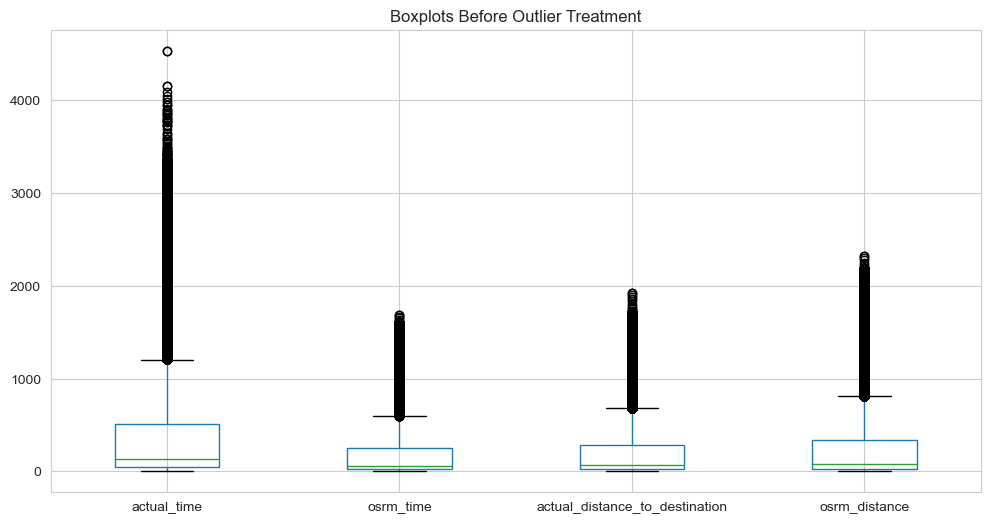

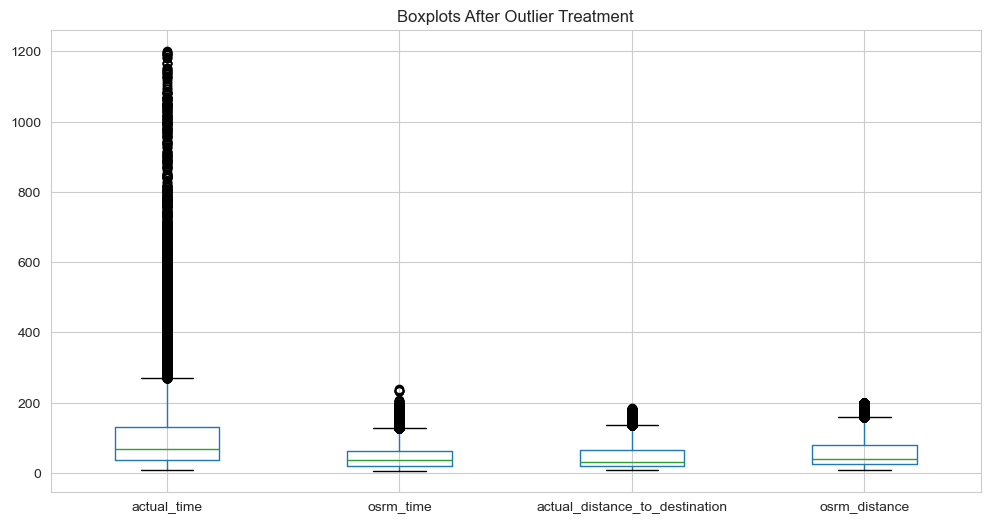

Dataset Shape After Outlier Treatment: (96506, 24)


In [7]:
# Detect missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

# 1. Handling Missing Values
# Fill numerical columns with median values
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))

# Fill categorical columns with mode values
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Verify missing values after treatment
print("\nMissing Values After Treatment:\n", df.isnull().sum())

# 2. Outlier Detection & Treatment (Using IQR Method)
# Function to remove outliers using IQR
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# List of numerical columns to check for outliers
outlier_cols = ["actual_time", "osrm_time", "actual_distance_to_destination", "osrm_distance"]

# Visualizing Outliers Before Treatment
plt.figure(figsize=(12, 6))
df[outlier_cols].boxplot()
plt.title("Boxplots Before Outlier Treatment")
plt.savefig("figures\Boxplots_Before_Outlier_Treatment.png")
plt.show()

# Apply IQR method to remove outliers
for col in outlier_cols:
    df = remove_outliers_iqr(df, col)

# Visualizing Outliers After Treatment
plt.figure(figsize=(12, 6))
df[outlier_cols].boxplot()
plt.title("Boxplots After Outlier Treatment")
plt.savefig("figures\Boxplots_After_Outlier_Treatment.png")
plt.show()

# Final dataset shape after cleaning
print("Dataset Shape After Outlier Treatment:", df.shape)

# Save cleaned dataset
df.to_csv("data\processed\data_cleaned.csv", index=False)

# 6. Checking relationship between aggregated fields

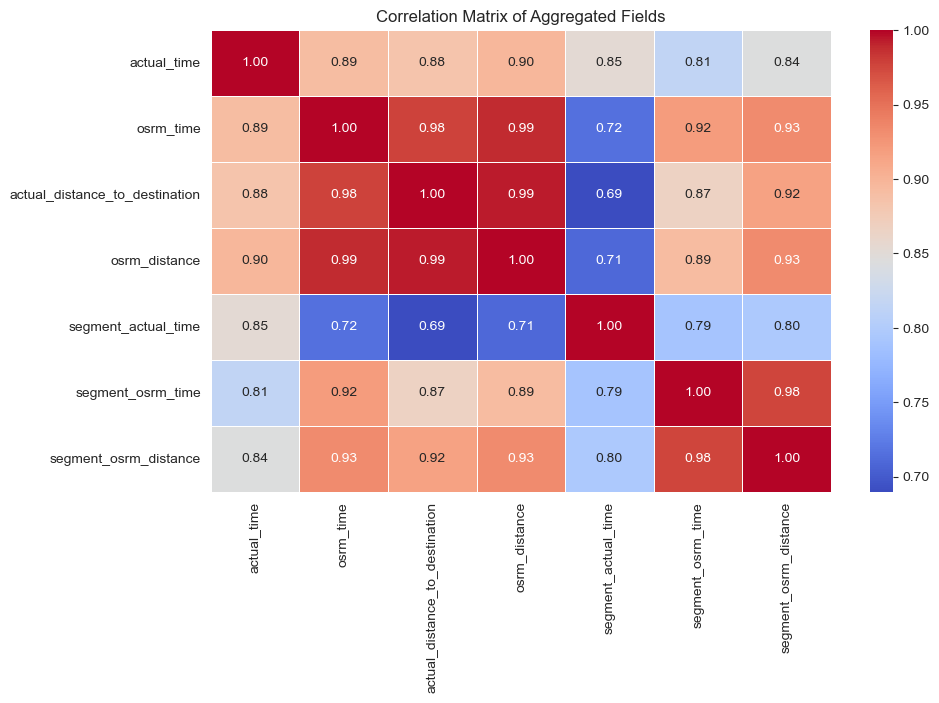

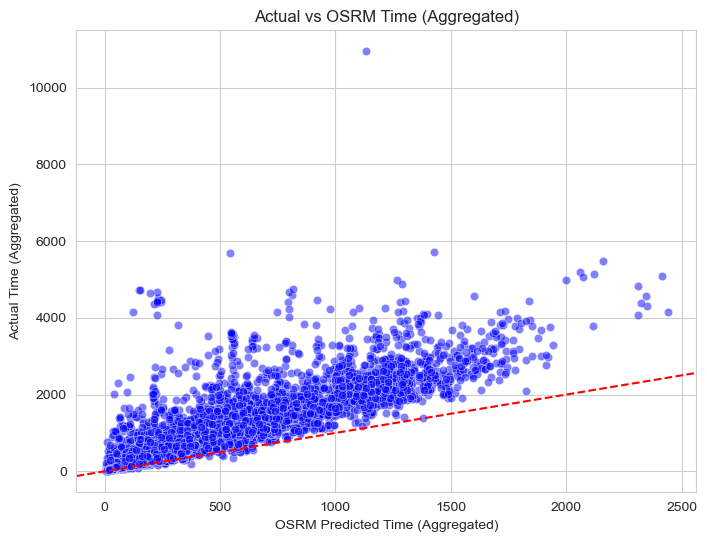

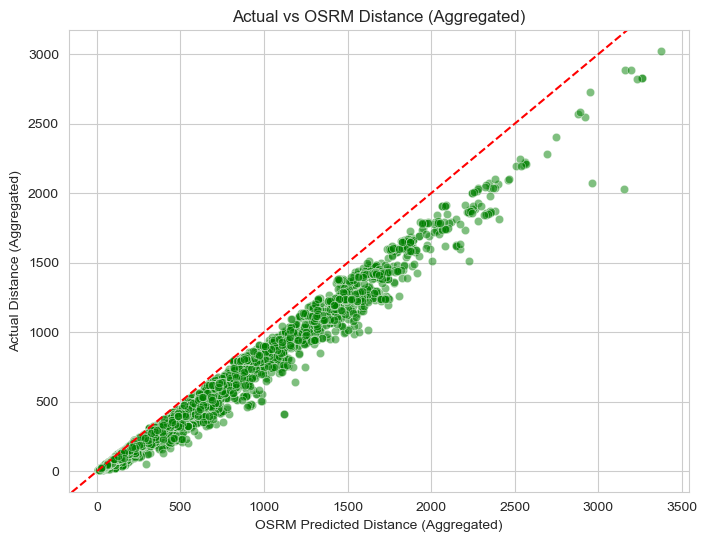

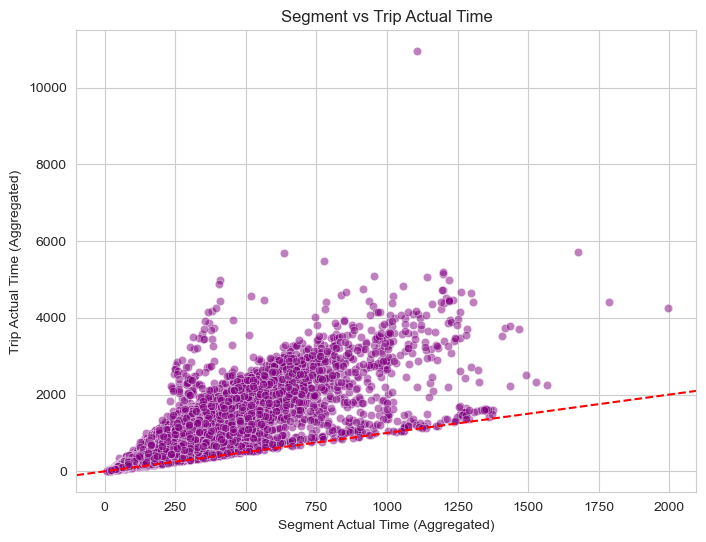

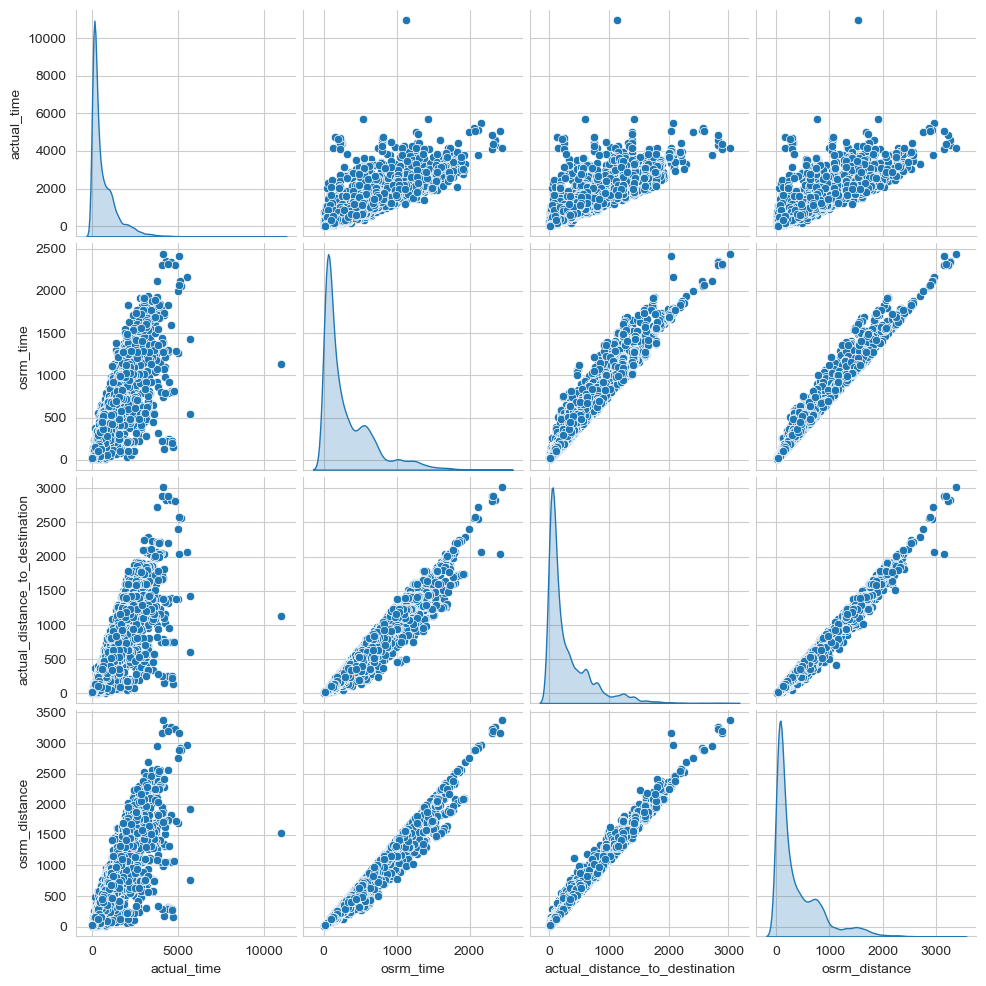

In [9]:
# Load the cleaned dataset
file_path = "data\processed\data_cleaned.csv"
df_cleaned = pd.read_csv(file_path)

# Aggregate data by trip_uuid
agg_df = df_cleaned.groupby("trip_uuid").agg({
    "actual_time": "sum",
    "osrm_time": "sum",
    "actual_distance_to_destination": "sum",
    "osrm_distance": "sum",
    "segment_actual_time": "sum",
    "segment_osrm_time": "sum",
    "segment_osrm_distance": "sum"
}).reset_index()

# 1. Correlation Matrix & Heatmap
corr_matrix = agg_df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Aggregated Fields")
plt.savefig("figures\Correlation_Matrix_of_Aggregated_Fields.png")
plt.show()

# 2. Scatter Plots for Key Relationships

# Actual Time vs OSRM Time
plt.figure(figsize=(8, 6))
sns.scatterplot(x=agg_df["osrm_time"], y=agg_df["actual_time"], alpha=0.5, color="blue")
plt.axline((0, 0), slope=1, linestyle="--", color="red")
plt.xlabel("OSRM Predicted Time (Aggregated)")
plt.ylabel("Actual Time (Aggregated)")
plt.title("Actual vs OSRM Time (Aggregated)")
plt.savefig("figures\Actual_vs_OSRM_Time_Aggregated.png")
plt.show()

# Actual Distance vs OSRM Distance
plt.figure(figsize=(8, 6))
sns.scatterplot(x=agg_df["osrm_distance"], y=agg_df["actual_distance_to_destination"], alpha=0.5, color="green")
plt.axline((0, 0), slope=1, linestyle="--", color="red")
plt.xlabel("OSRM Predicted Distance (Aggregated)")
plt.ylabel("Actual Distance (Aggregated)")
plt.title("Actual vs OSRM Distance (Aggregated)")
plt.savefig("figures\Actual_vs_OSRM_Distance_Aggregated.png")
plt.show()

# Segment Actual Time vs Aggregated Actual Time
plt.figure(figsize=(8, 6))
sns.scatterplot(x=agg_df["segment_actual_time"], y=agg_df["actual_time"], alpha=0.5, color="purple")
plt.axline((0, 0), slope=1, linestyle="--", color="red")
plt.xlabel("Segment Actual Time (Aggregated)")
plt.ylabel("Trip Actual Time (Aggregated)")
plt.title("Segment vs Trip Actual Time")
plt.savefig("figures\Segment_vs_Trip_Actual_Time.png")
plt.show()

# 3. Pair Plot for Multiple Comparisons
sns.pairplot(agg_df[["actual_time", "osrm_time", "actual_distance_to_destination", "osrm_distance"]], diag_kind="kde")
plt.savefig("figures\Pairplot_of_Aggregated_Fields.png")
plt.show()

# 7. Handling categorical values 

In [49]:
# Identify categorical columns
cat_cols = df_cleaned.select_dtypes(include=["object"]).columns.tolist()
print("Categorical Columns:", cat_cols)

# Define columns for one-hot encoding and label encoding
one_hot_cols = ["route_type"]  # Few unique values, suitable for one-hot encoding
label_encode_cols = ["source_name", "destination_name"]  # Many unique values, suitable for label encoding

# Apply One-Hot Encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=one_hot_cols, drop_first=True)

# Apply Label Encoding
label_enc = LabelEncoder()
for col in label_encode_cols:
    df_cleaned[col] = label_enc.fit_transform(df_cleaned[col])

# Verify encoding results
print("Dataset Shape After Encoding:", df_cleaned.shape)

# Save the processed dataset
df_cleaned.to_csv("E:\Business Case Studies\Logistic_Service_Platform_FE\data\processed\data_encoded.csv", index=False)
df_cleaned

Categorical Columns: ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
Dataset Shape After Encoding: (96506, 24)


,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,route_type_FTL
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,48,IND388620AAB,740,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727,0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,48,IND388620AAB,740,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111,0
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,48,IND388620AAB,740,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714,0
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,48,IND388620AAB,740,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000,0
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,48,IND388620AAB,740,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96501,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1352,IND000000ACB,520,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,45,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000,0
96502,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1352,IND000000ACB,520,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,54,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095,0
96503,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1352,IND000000ACB,520,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,63,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235,0
96504,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1352,IND000000ACB,520,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,427.0,True,72,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630,0


# 8. Column Normalization /Column Standardization

In [51]:
# Load the encoded dataset
file_path = "data/processed/data_encoded.csv"
df_encoded = pd.read_csv(file_path)

# Identify numerical columns for scaling
num_cols = df_encoded.select_dtypes(include=["number"]).columns.tolist()

# Apply MinMax Scaling (Normalization)
minmax_scaler = MinMaxScaler()
df_normalized = df_encoded.copy()
df_normalized[num_cols] = minmax_scaler.fit_transform(df_normalized[num_cols])

# Apply Standard Scaling (Standardization)
standard_scaler = StandardScaler()
df_standardized = df_encoded.copy()
df_standardized[num_cols] = standard_scaler.fit_transform(df_standardized[num_cols])

# Save the transformed datasets
df_normalized.to_csv("data/processed/data_normalized.csv", index=False)
df_standardized.to_csv("data/processed/data_standardized.csv", index=False)

print("Normalization & Standardization Completed!")
print("Saved normalized and standardized datasets.")
display(df_normalized, df_standardized)

Normalization & Standardization Completed!
Saved normalized and standardized datasets.


,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,route_type_FTL
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,0.032064,IND388620AAB,0.504431,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,0.014618,True,0.000000,2018-09-20 04:27:55,0.008183,0.004195,0.021459,0.015461,0.014782,0.160371,0.058201,0.051197,0.042473,0.0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,0.032064,IND388620AAB,0.504431,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,0.014618,True,0.052023,2018-09-20 04:17:55,0.056637,0.012584,0.060086,0.066484,0.013830,0.157520,0.047619,0.041756,0.042196,0.0
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,0.032064,IND388620AAB,0.504431,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,0.014618,True,0.104046,2018-09-20 04:01:19.505586,0.106228,0.026007,0.094421,0.123029,0.016823,0.161796,0.037037,0.046276,0.044214,0.0
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,0.032064,IND388620AAB,0.504431,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,0.014618,True,0.156069,2018-09-20 03:39:57,0.154566,0.044463,0.145923,0.191115,0.018414,0.165360,0.063492,0.055720,0.043294,0.0
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,0.032064,IND388620AAB,0.504431,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,0.014618,False,0.173410,2018-09-20 03:33:55,0.173192,0.049497,0.163090,0.236372,0.018354,0.154669,0.026455,0.016753,0.042348,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96501,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,0.903140,IND000000ACB,0.354465,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.090144,True,0.208092,2018-09-20 21:57:20,0.206663,0.071309,0.231760,0.308052,0.018632,0.158945,0.063492,0.035025,0.042005,0.0
96502,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,0.903140,IND000000ACB,0.354465,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.090144,True,0.260116,2018-09-20 21:31:18,0.257016,0.093121,0.300429,0.400881,0.018793,0.168924,0.111111,0.074333,0.042414,0.0
96503,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,0.903140,IND000000ACB,0.354465,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.090144,True,0.312139,2018-09-20 21:11:18,0.325818,0.109899,0.351931,0.460538,0.018950,0.164647,0.179894,0.088593,0.041297,0.0
96504,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,0.903140,IND000000ACB,0.354465,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.090144,True,0.364162,2018-09-20 20:53:19,0.368663,0.125000,0.394850,0.534663,0.019229,0.162509,0.142857,0.080819,0.041368,0.0


,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,route_type_FTL
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,-1.442975,IND388620AAB,0.209425,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,-0.596710,True,-0.957702,2018-09-20 04:27:55,-0.942189,-0.879658,-1.025651,-0.992803,-0.464417,-0.382528,-0.456804,-0.553445,-0.206188,-1.067203
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,-1.442975,IND388620AAB,0.209425,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,-0.596710,True,-0.722557,2018-09-20 04:17:55,-0.720898,-0.777330,-0.773050,-0.780139,-0.500469,-0.458841,-0.626617,-0.721521,-0.237306,-1.067203
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,-1.442975,IND388620AAB,0.209425,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,-0.596710,True,-0.487412,2018-09-20 04:01:19.505586,-0.494420,-0.613606,-0.548516,-0.544459,-0.387162,-0.344371,-0.796430,-0.641060,-0.011147,-1.067203
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,-1.442975,IND388620AAB,0.209425,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,-0.596710,True,-0.252267,2018-09-20 03:39:57,-0.273660,-0.388486,-0.211715,-0.260679,-0.326968,-0.248979,-0.371898,-0.472915,-0.114294,-1.067203
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,-1.442975,IND388620AAB,0.209425,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,-0.596710,False,-0.173885,2018-09-20 03:33:55,-0.188591,-0.327089,-0.099447,-0.072049,-0.329221,-0.535155,-0.966243,-1.166695,-0.220191,-1.067203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96501,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1.589262,IND000000ACB,-0.307628,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.027342,True,-0.017122,2018-09-20 21:57:20,-0.035733,-0.061037,0.349621,0.226711,-0.318706,-0.420685,-0.371898,-0.841368,-0.258699,-1.067203
96502,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1.589262,IND000000ACB,-0.307628,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.027342,True,0.218023,2018-09-20 21:31:18,0.194228,0.205014,0.798690,0.613618,-0.312618,-0.153587,0.392260,-0.141523,-0.212856,-1.067203
96503,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1.589262,IND000000ACB,-0.307628,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.027342,True,0.453168,2018-09-20 21:11:18,0.508446,0.409669,1.135491,0.862269,-0.306689,-0.268058,1.496043,0.112370,-0.337980,-1.067203
96504,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,1.589262,IND000000ACB,-0.307628,2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,0.027342,True,0.688313,2018-09-20 20:53:19,0.704121,0.593859,1.416159,1.171220,-0.296112,-0.325293,0.901699,-0.026034,-0.330010,-1.067203


# 9. Business Insights

source_state
Karnataka         12653
Maharashtra       12561
Haryana           11297
Tamil Nadu         7173
Uttar Pradesh      6172
Gujarat            4994
Telangana          4879
Rajasthan          4854
Andhra Pradesh     4762
West Bengal        4414
Name: count, dtype: int64

destination_state
Karnataka         13041
Maharashtra       12038
Haryana           10464
Tamil Nadu         6980
Uttar Pradesh      6640
Telangana          5105
Rajasthan          5048
Gujarat            5028
Andhra Pradesh     4880
West Bengal        4677
Name: count, dtype: int64

,source_state,destination_state,trip_count
72,Karnataka,Karnataka,10923
98,Maharashtra,Maharashtra,10581
129,Tamil Nadu,Tamil Nadu,6548
144,Uttar Pradesh,Uttar Pradesh,4770
44,Haryana,Haryana,4622
34,Gujarat,Gujarat,4269
124,Rajasthan,Rajasthan,4099
154,West Bengal,West Bengal,3935
137,Telangana,Telangana,3800
0,Andhra Pradesh,Andhra Pradesh,3755


,source_state,destination_state,avg_distance,avg_time
136,Telangana,Orissa,103.813758,137.603175
35,Gujarat,Haryana,101.619233,142.696000
67,Jharkhand,Uttar Pradesh,100.643509,129.208333
149,West Bengal,Bihar,100.396319,124.375000
120,Rajasthan,Delhi,100.360985,153.205357
17,Bihar,Uttar Pradesh,100.304584,128.031250
76,Karnataka,Orissa,100.246479,136.232759
64,Jharkhand,Bihar,100.179346,152.625000
36,Gujarat,Karnataka,100.083686,150.843750
26,Delhi,Punjab,100.003690,134.797619


C:\Users\chasm\AppData\Local\Temp\ipykernel_16008\1020012501.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.index, y=top_sources.values, palette="Blues_r")


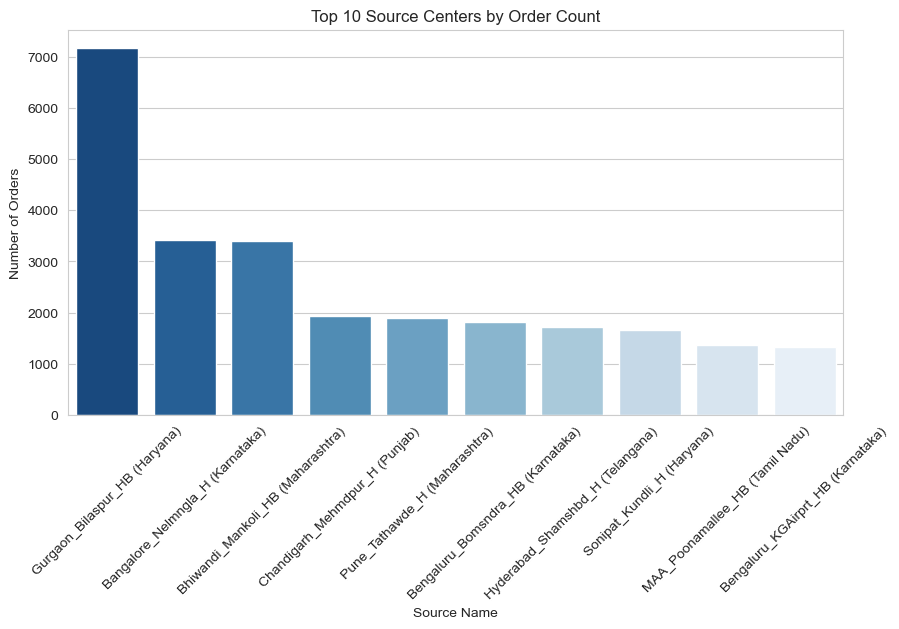

C:\Users\chasm\AppData\Local\Temp\ipykernel_16008\1020012501.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corridors.index, y=top_corridors.values, palette="Reds_r")


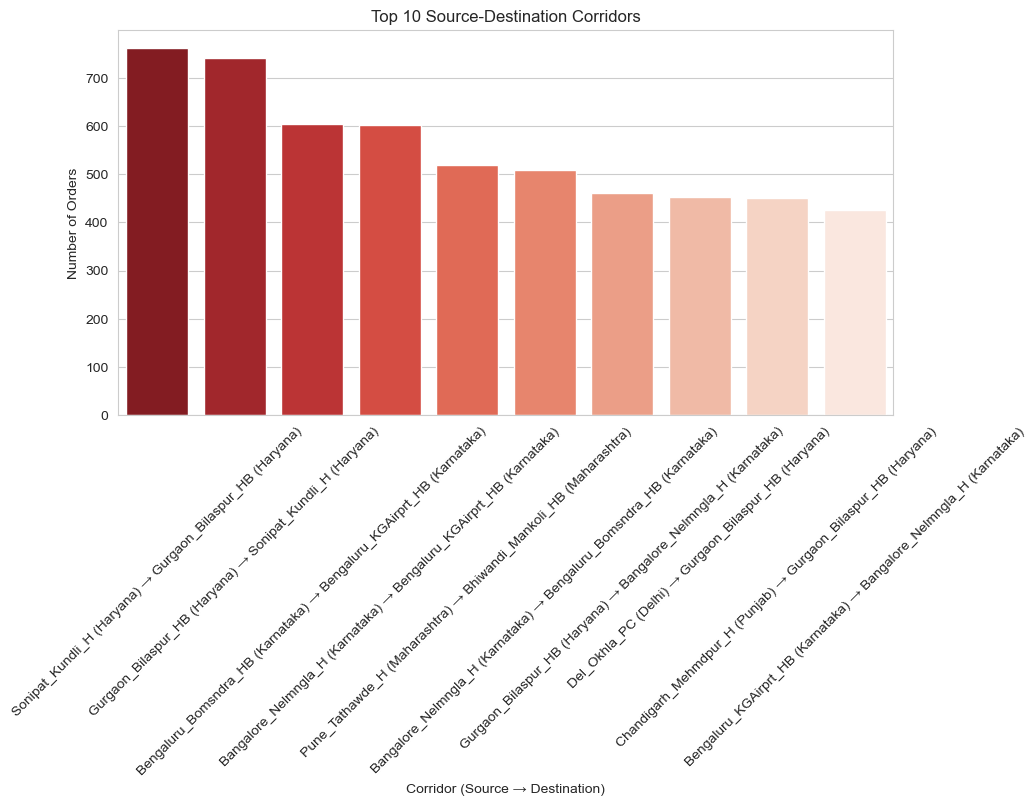

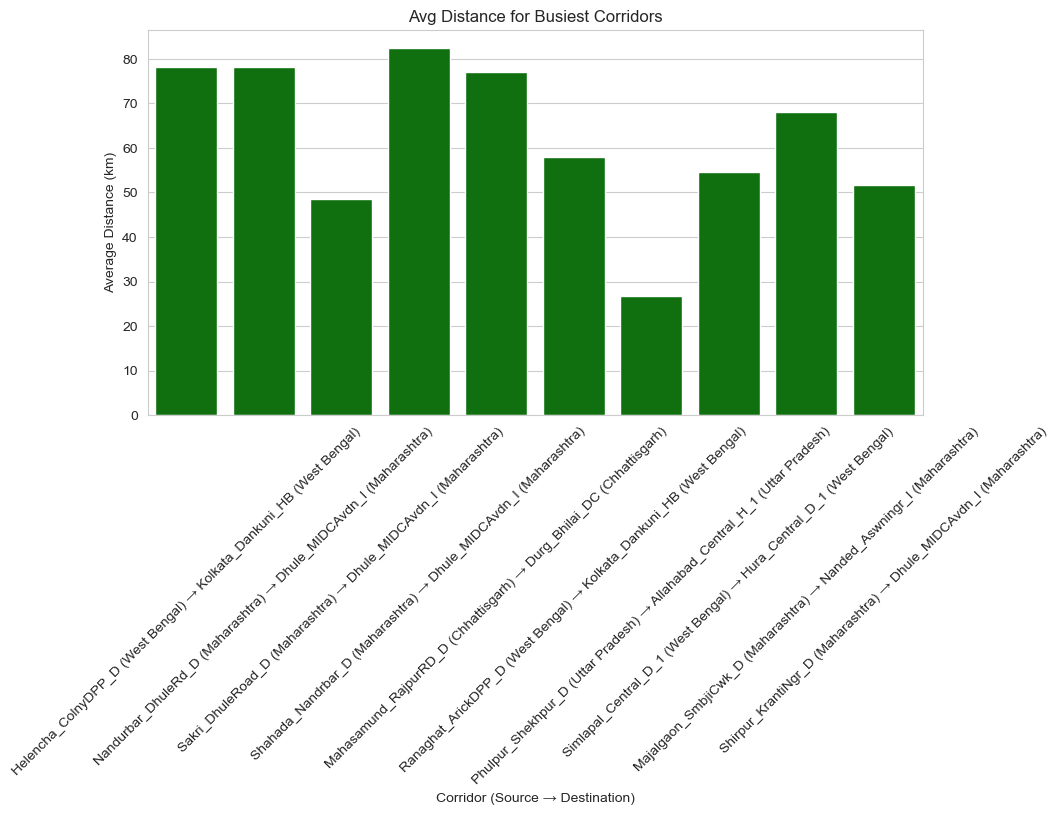

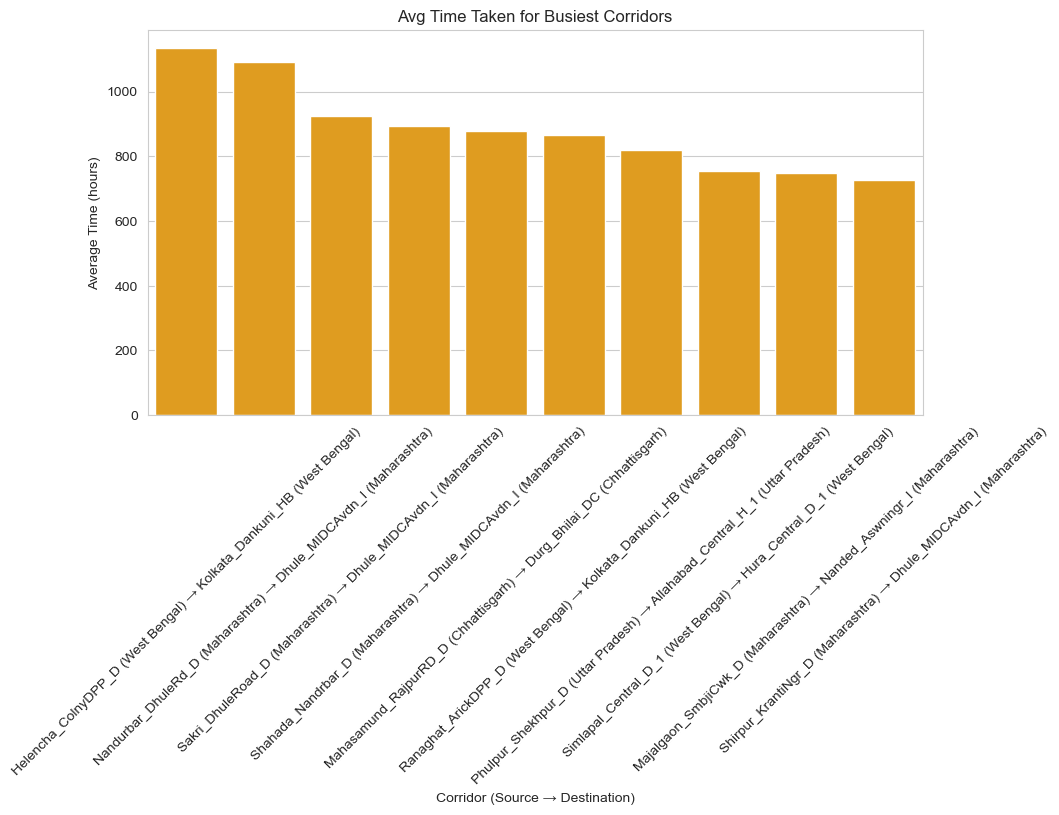

C:\Users\chasm\AppData\Local\Temp\ipykernel_16008\1020012501.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corridor_delays.index, y=corridor_delays.values, palette="coolwarm")


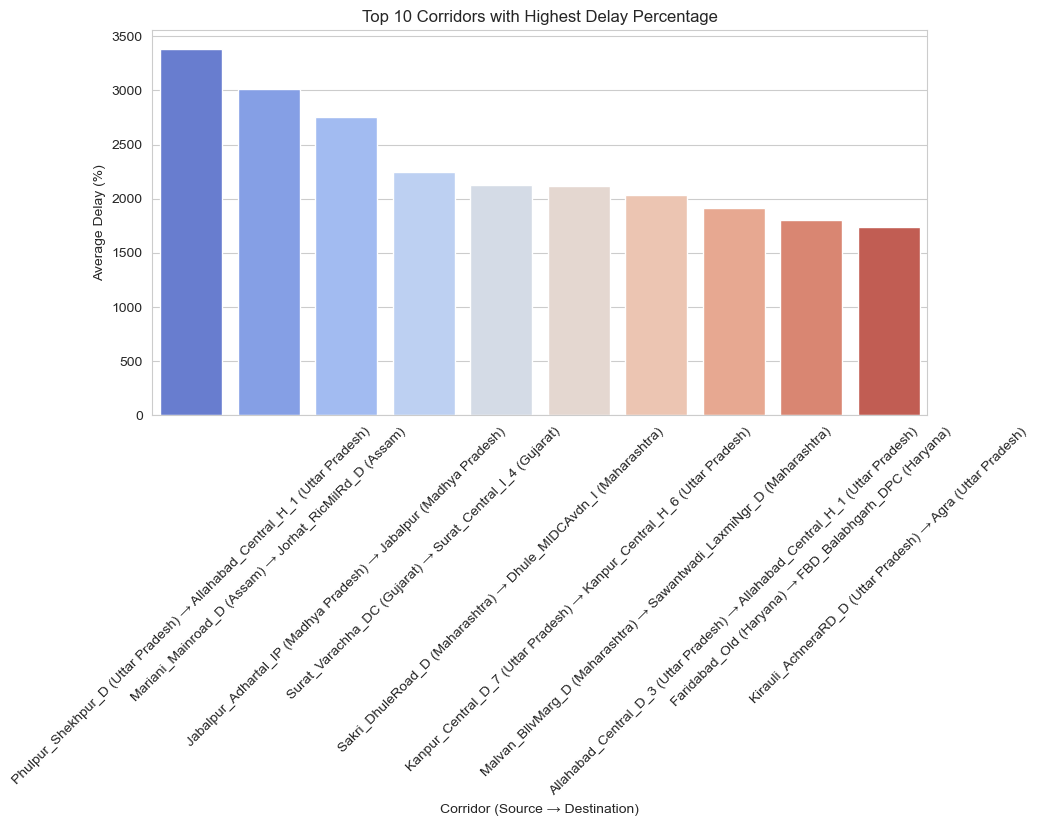

In [10]:
# Extract state names from source_name and destination_name
df_cleaned['source_state'] = df_cleaned['source_name'].str.extract(r'\((.*?)\)')
df_cleaned['destination_state'] = df_cleaned['destination_name'].str.extract(r'\((.*?)\)')

# Count the number of trips from each source state
top_source_states = df_cleaned['source_state'].value_counts().head(10)

# Count the number of trips to each destination state
top_destination_states = df_cleaned['destination_state'].value_counts().head(10)

# Identify the busiest corridors (source-destination pairs)
busiest_corridors = df_cleaned.groupby(['source_state', 'destination_state']).size().reset_index(name='trip_count')
busiest_corridors = busiest_corridors.sort_values(by='trip_count', ascending=False).head(10)

# Compute average distance and average time taken per corridor
corridor_stats = df_cleaned.groupby(['source_state', 'destination_state']).agg(
    avg_distance=('actual_distance_to_destination', 'mean'),
    avg_time=('actual_time', 'mean')
).reset_index().sort_values(by='avg_distance', ascending=False).head(10)

# Display results
display(top_source_states, top_destination_states, busiest_corridors, corridor_stats)

###Check from where most orders are coming from (State, Corridor)
# Top source centers
top_sources = df_cleaned["source_name"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_sources.index, y=top_sources.values, palette="Blues_r")
plt.xticks(rotation=45)
plt.title("Top 10 Source Centers by Order Count")
plt.xlabel("Source Name")
plt.ylabel("Number of Orders")
plt.savefig("figures\Top_10_Source_Centers_by_Order_Count.png")
plt.show()

# Top source-destination corridors
df_cleaned["corridor"] = df_cleaned["source_name"] + " → " + df_cleaned["destination_name"]
top_corridors = df_cleaned["corridor"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_corridors.index, y=top_corridors.values, palette="Reds_r")
plt.xticks(rotation=45)
plt.title("Top 10 Source-Destination Corridors")
plt.xlabel("Corridor (Source → Destination)")
plt.ylabel("Number of Orders")
plt.savefig("figures\Top_10_Source_Destination_Corridors.png")
plt.show()

###Busiest Corridor Analysis (Avg Distance & Time)
corridor_stats = df_cleaned.groupby("corridor").agg({
    "actual_distance_to_destination": "mean",
    "actual_time": "mean"
}).sort_values(by="actual_time", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=corridor_stats.index, y=corridor_stats["actual_distance_to_destination"], color="green")
plt.xticks(rotation=45)
plt.title("Avg Distance for Busiest Corridors")
plt.xlabel("Corridor (Source → Destination)")
plt.ylabel("Average Distance (km)")
plt.savefig("figures\Avg_Distance_for_Busiest_Corridors.png")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=corridor_stats.index, y=corridor_stats["actual_time"], color="orange")
plt.xticks(rotation=45)
plt.title("Avg Time Taken for Busiest Corridors")
plt.xlabel("Corridor (Source → Destination)")
plt.ylabel("Average Time (hours)")
plt.savefig("figures\Avg_Time_Taken_for_Busiest_Corridors.png")
plt.show()

###Delivery Performance (Actual vs OSRM Time)
df_cleaned["delay_percentage"] = ((df_cleaned["actual_time"] - df_cleaned["osrm_time"]) / df_cleaned["osrm_time"]) * 100
corridor_delays = df_cleaned.groupby("corridor")["delay_percentage"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=corridor_delays.index, y=corridor_delays.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Top 10 Corridors with Highest Delay Percentage")
plt.xlabel("Corridor (Source → Destination)")
plt.ylabel("Average Delay (%)")
plt.savefig("figures\Top_10_Corridors_with_Highest_Delay_Percentage.png")
plt.show()

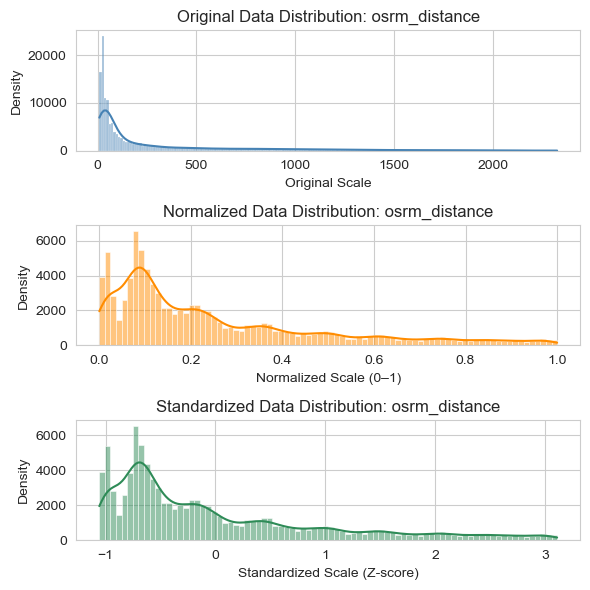

In [18]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(6, 6))

# Raw data distribution
sns.histplot(
    df_cleaned[col],
    kde=True,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title(f"Original Data Distribution: {col}")
axes[0].set_xlabel("Original Scale")
axes[0].set_ylabel("Density")

# Normalized data distribution
sns.histplot(
    df_normalized[col],
    kde=True,
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title(f"Normalized Data Distribution: {col}")
axes[1].set_xlabel("Normalized Scale (0–1)")
axes[1].set_ylabel("Density")

#Standardized data distribution
sns.histplot(
    df_standardized[col],
    kde=True,
    ax=axes[2],
    color="seagreen"
)
axes[2].set_title(f"Standardized Data Distribution: {col}")
axes[2].set_xlabel("Standardized Scale (Z-score)")
axes[2].set_ylabel("Density")

plt.tight_layout()
plt.savefig(f"figures\Data_Distribution_{col}.png")
plt.show()

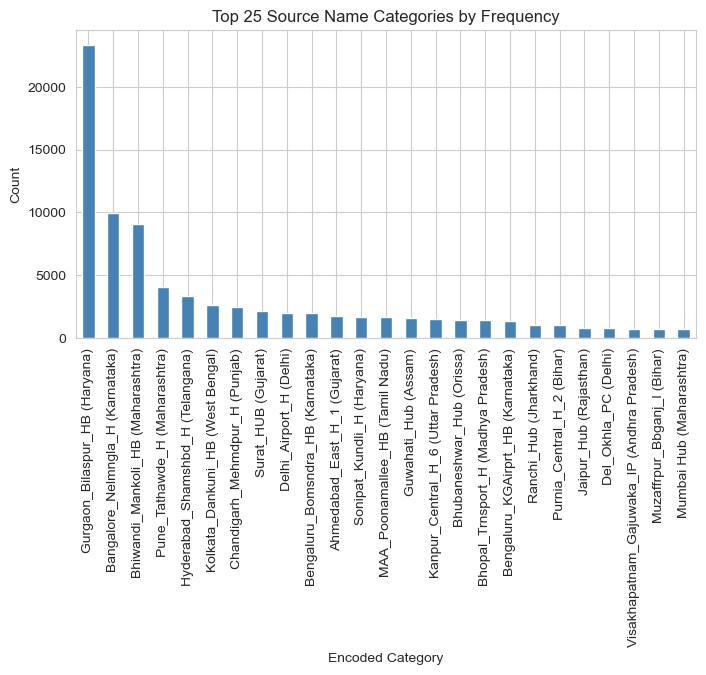

In [21]:
plt.figure(figsize=(8, 4))

df_cleaned["source_name"].value_counts().head(25).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 25 Source Name Categories by Frequency")
plt.xlabel("Encoded Category")
plt.ylabel("Count")
# plt.tight_layout()
plt.savefig(f"figures\Top_25_Source_Name_Categories_by_Frequency.png")
plt.show()

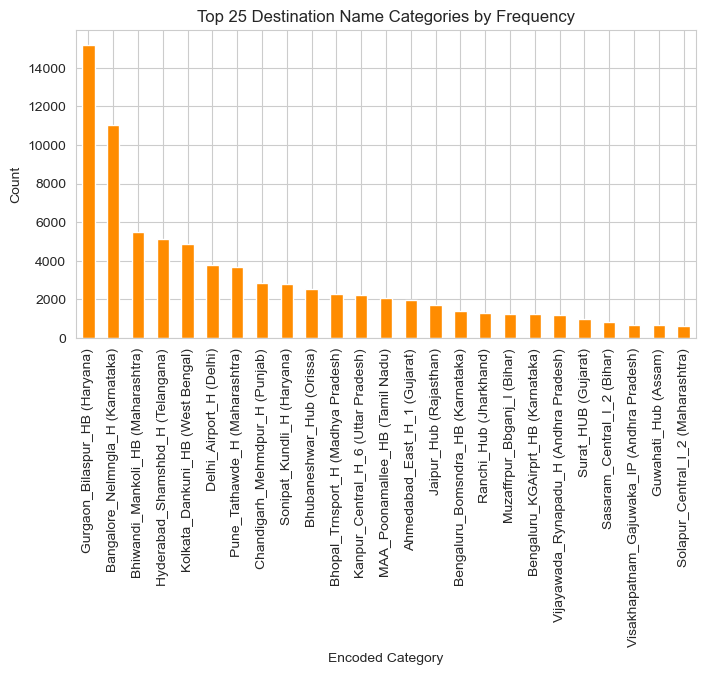

In [22]:
plt.figure(figsize=(8, 4))

df_cleaned["destination_name"].value_counts().head(25).plot(
    kind="bar",
    color="darkorange"
)

plt.title("Top 25 Destination Name Categories by Frequency")
plt.xlabel("Encoded Category")
plt.ylabel("Count")
# plt.tight_layout()
plt.savefig(f"figures\Top_25_Destination_Name_Categories_by_Frequency.png")
plt.show()

C:\Users\chasm\AppData\Local\Temp\ipykernel_16008\2716884230.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


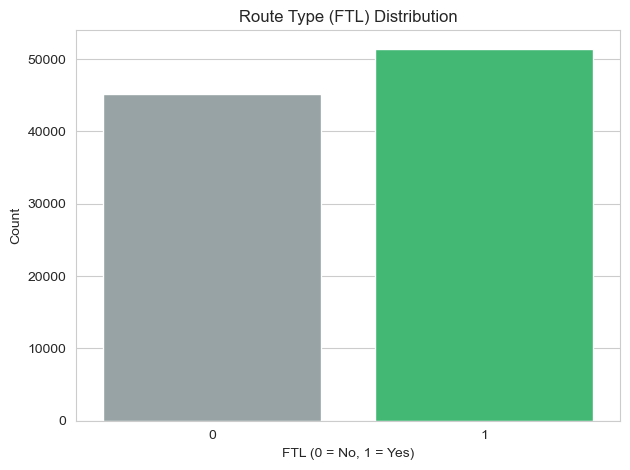

In [30]:
sns.countplot(
    x="route_type_FTL",
    data=df_encoded,
    palette=["#95a5a6", "#2ecc71"]
)

plt.title("Route Type (FTL) Distribution")
plt.xlabel("FTL (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"figures\Route_Type_FTL_Distribution.png")
plt.show()

## 9.1 Check from where most orders are coming from (State, Corridor, etc.)

**The top 3 states with the highest number of trip origins are:**
-    Haryana (27,499 trips)
-    Maharashtra (21,401 trips)
-    Karnataka (19,578 trips)

**The top 3 states receiving the most shipments are:**
-    Karnataka (21,065 trips)
-    Haryana (20,622 trips)
-    Maharashtra (18,196 trips)

## 9.2 Busiest Corridor, Avg Distance, and Avg Time Taken

**The busiest intra-state corridors (shipments within the same state):**

-    Maharashtra ↔ Maharashtra (11,876 trips)
-    Karnataka ↔ Karnataka (11,107 trips)
-    Tamil Nadu ↔ Tamil Nadu (6,549 trips)

**The busiest inter-state corridors (shipments between different states):**

-    Haryana ↔ Karnataka (4,976 trips)
-    Haryana ↔ Tamil Nadu (4,508 trips)
-    Gujarat ↔ Gujarat (4,491 trips)

**The longest average distance corridors:**

-    Punjab → Karnataka (1,051 km, avg time: 1683 minutes)
-    Haryana → Tamil Nadu (877 km, avg time: 1457 minutes)
-    Karnataka → Haryana (869 km, avg time: 1472 minutes)

# 10. Recommendations

**Optimize Operations in Haryana, Maharashtra, and Karnataka**

-    These states generate the most shipments, indicating a need for efficient sorting centers and additional delivery hubs in these regions.

**Improve Logistics Efficiency for Long-Distance Routes**

-    Punjab to Karnataka and Haryana to Tamil Nadu have long distances and high average delivery times.
-    Optimize routing and explore multi-modal transport (rail or air) to reduce time.

**Enhance Same-State Deliveries in Maharashtra and Karnataka**

-    Since intra-state shipments dominate, investing in last-mile delivery efficiency, more distribution centers, and better warehouse locations can improve speed.

**Invest in the Top 10 Busiest Corridors**

-    Identifying bottlenecks in these corridors and implementing real-time route optimization can reduce delays and improve delivery performance.

**Balance Workload Based on Demand**

-    Deploy more vehicles and manpower in peak corridors to handle the large shipment volume efficiently.